# 1. Ilość włokien na mm^2 w zależności od powiększenia

In [2]:
import os
import cv2
import json
from numpy import sqrt, power
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import glob
import seaborn as sns
from scipy.stats import skew

In [3]:
input_dir = "data/raw_images/manual_labels/"
img_dir = "data/raw_images/"

fibers_per_sq_mm = {}

max_x = 0
max_y = 0
min_x = float('inf')
min_y = float('inf')

for filename in os.listdir(input_dir):
    print(f"Processing {filename}...")
    params = filename.split('_')
    picture = cv2.imread(os.path.join(img_dir, filename.replace('.json', '.png')), cv2.IMREAD_GRAYSCALE)
    if picture is not None:
        obj = json.load(open(os.path.join(input_dir, filename)))
        fiber_count = len(obj['shapes'])

        for shape in obj['shapes']:
            for point in shape['points']:
                x, y = point
                max_x = max(max_x, x)
                max_y = max(max_y, y)
                min_x = min(min_x, x)
                min_y = min(min_y, y)

        height_px, width_px = max_y - min_y, max_x - min_x
        height_mm = height_px / int(params[1])
        width_mm = width_px / int(params[1])
        area_mm2 = height_mm * width_mm

        if fibers_per_sq_mm.get(params[0]) is not None:
            fibers_per_sq_mm[params[0]].append(fiber_count / area_mm2)
        else:
            fibers_per_sq_mm[params[0]] = [fiber_count / area_mm2]

for key, value in fibers_per_sq_mm.items():
    print(f"Magnification {key}x fibers density: {sum(value) / len(value):.2f} fibers/mm²")

Processing 0100_1008_01.json...
Processing 0500_5040_01.json...
Processing 1000_10080_02.json...
Processing 2000_20150_01.json...
Processing 2000_20150_02.json...
Processing 4000_40300_01.json...
Magnification 0100x fibers density: 5107.07 fibers/mm²
Magnification 0500x fibers density: 4680.00 fibers/mm²
Magnification 1000x fibers density: 5070.67 fibers/mm²
Magnification 2000x fibers density: 5332.25 fibers/mm²
Magnification 4000x fibers density: 5687.74 fibers/mm²


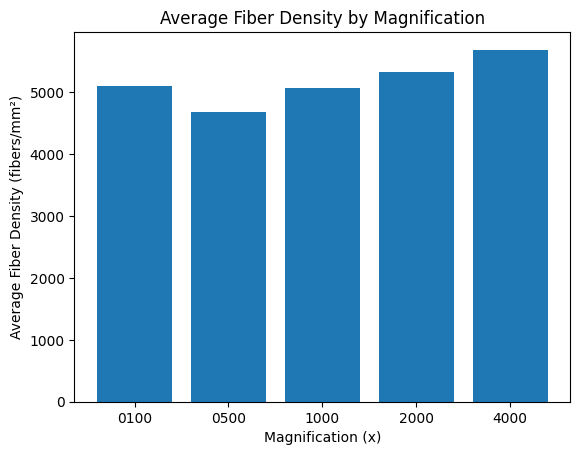

In [4]:
magnifications = list(fibers_per_sq_mm.keys())
densities = [sum(values) / len(values) for values in fibers_per_sq_mm.values()]
plt.bar(magnifications, densities)
plt.xlabel('Magnification (x)')
plt.ylabel('Average Fiber Density (fibers/mm²)')
plt.title('Average Fiber Density by Magnification')
plt.show()

# 2. Średnia średnica względem powiększenia

In [5]:
input_dir = "data/raw_images/manual_labels/"
img_dir = "data/raw_images/"

fibers_diameters = {}

for filename in os.listdir(input_dir):
    print(f"Processing {filename}...")
    params = filename.split('_')

    obj = json.load(open(os.path.join(input_dir, filename)))
    for shape in obj['shapes']:
        diameter_px = sqrt(power(shape['points'][0][0] - shape['points'][1][0], 2) \
                           + power(shape['points'][0][1] - shape['points'][1][1], 2))
        diameter_mm = diameter_px / int(params[1])

        if fibers_diameters.get(params[0]) is not None:
            fibers_diameters[params[0]].append(diameter_mm)
        else:
            fibers_diameters[params[0]] = [diameter_mm]

for key, value in fibers_diameters.items():
    print(f"Magnification {key}x mean diameter: {str.format('{:.2e}mm', sum(value) / len(value))}")

Processing 0100_1008_01.json...
Processing 0500_5040_01.json...
Processing 1000_10080_02.json...
Processing 2000_20150_01.json...
Processing 2000_20150_02.json...
Processing 4000_40300_01.json...
Magnification 0100x mean diameter: 6.30e-03mm
Magnification 0500x mean diameter: 6.63e-03mm
Magnification 1000x mean diameter: 6.59e-03mm
Magnification 2000x mean diameter: 6.46e-03mm
Magnification 4000x mean diameter: 6.41e-03mm


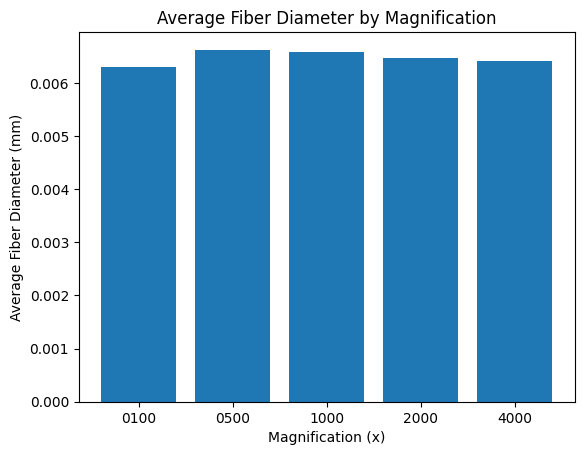

In [6]:
magnifications = list(fibers_diameters.keys())
densities = [sum(values) / len(values) for values in fibers_diameters.values()]
plt.bar(magnifications, densities)
plt.xlabel('Magnification (x)')
plt.ylabel('Average Fiber Diameter (mm)')
plt.title('Average Fiber Diameter by Magnification')
plt.show()

# 3. Rozkład średnic

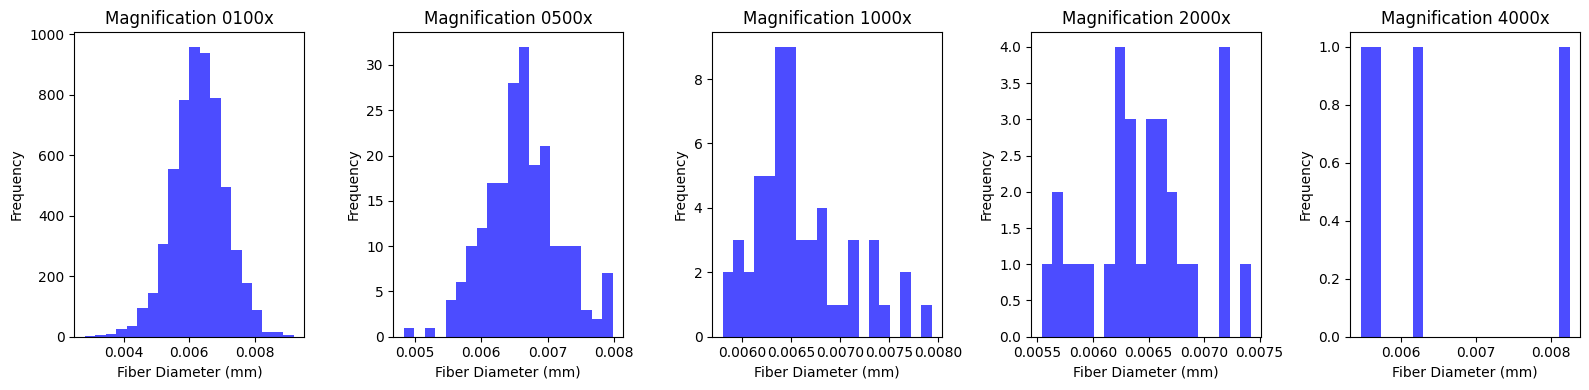

In [7]:
fig, axs = plt.subplots(1, len(magnifications), figsize=(16, 4))
for i, mag in enumerate(magnifications):
    axs[i].hist(fibers_diameters[mag], bins=20, color='blue', alpha=0.7)
    axs[i].set_title(f'Magnification {mag}x')
    axs[i].set_xlabel('Fiber Diameter (mm)')
    axs[i].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

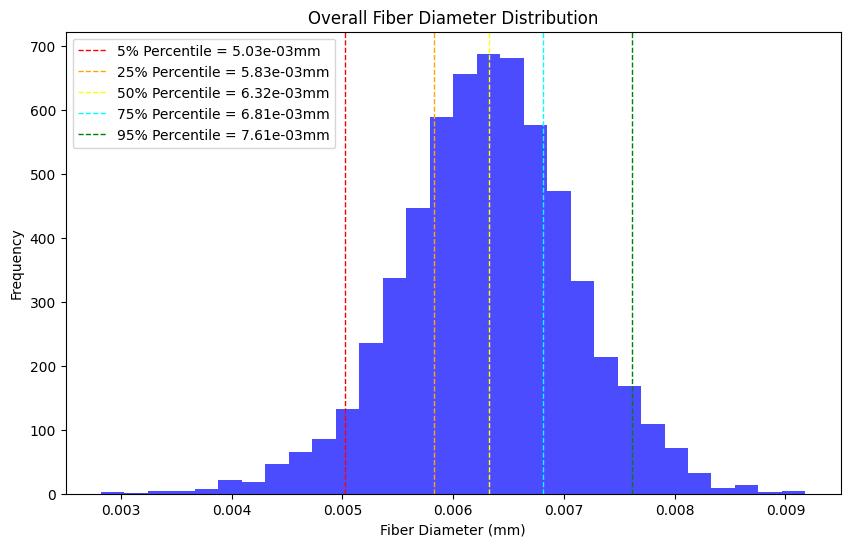

In [8]:
percentiles = [5, 25, 50, 75, 95]
colors = ['red', 'orange', 'yellow', 'cyan', 'green']

all_diameters = []
for diameters in fibers_diameters.values():
    all_diameters.extend(diameters)
plt.figure(figsize=(10, 6))
plt.hist(all_diameters, bins=30, color='blue', alpha=0.7)

for i, (percentile, color) in enumerate(zip(percentiles, colors)):
    plt.axvline(np.percentile(all_diameters, percentile), color=color, linestyle='dashed', linewidth=1, label=f'{percentile}% Percentile = {np.percentile(all_diameters, percentile):.2e}mm')

plt.title('Overall Fiber Diameter Distribution')
plt.xlabel('Fiber Diameter (mm)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

# 4. Analiza kontrastu

In [9]:


def analyze_image_dataset(directory_path, extension="*.png"):
    search_pattern = os.path.join(directory_path, extension)
    image_files = glob.glob(search_pattern)
    
    if not image_files:
        print(f"No images found matching {search_pattern}")
        return

    statistics = []

    for img_path in image_files:
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if image is not None:
            statistics.append({
                "Filename": os.path.basename(img_path),
                "Med_Intensity": np.median(image),
                "Mean_Intensity": np.mean(image),
                "Std_Deviation": np.std(image),
                "Min_Intensity": np.min(image),
                "Max_Intensity": np.max(image)
            })
        else:
            print(f"Failed to read: {img_path}")

    df = pd.DataFrame(statistics)
    return df

stats = analyze_image_dataset("data/raw_images/")

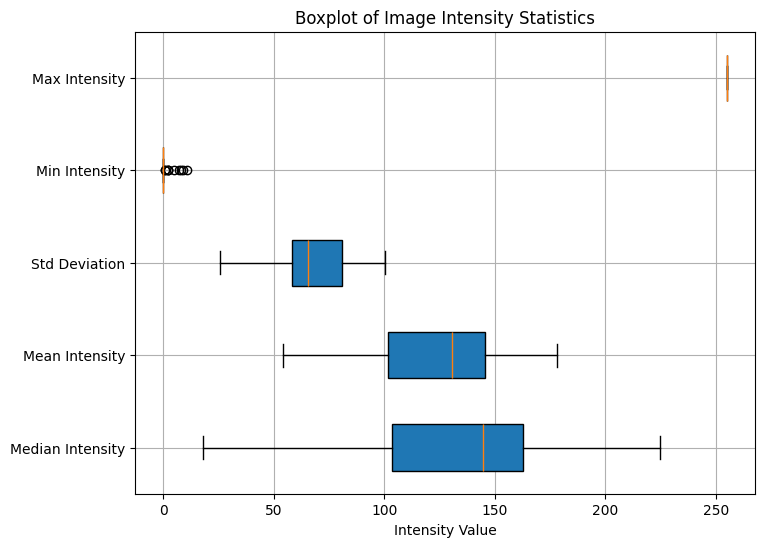

In [10]:
def show_boxplot_with_whiskers_of_mean_std_min_max_intensity(df):
    plt.figure(figsize=(8, 6))
    plt.boxplot(
        [df['Med_Intensity'], df['Mean_Intensity'], df['Std_Deviation'], df['Min_Intensity'], df['Max_Intensity']],
        vert=False,
        patch_artist=True,
        tick_labels=['Median Intensity', 'Mean Intensity', 'Std Deviation', 'Min Intensity', 'Max Intensity'])
    plt.title('Boxplot of Image Intensity Statistics')
    plt.xlabel('Intensity Value')
    plt.grid(True)
    plt.show()

show_boxplot_with_whiskers_of_mean_std_min_max_intensity(stats)

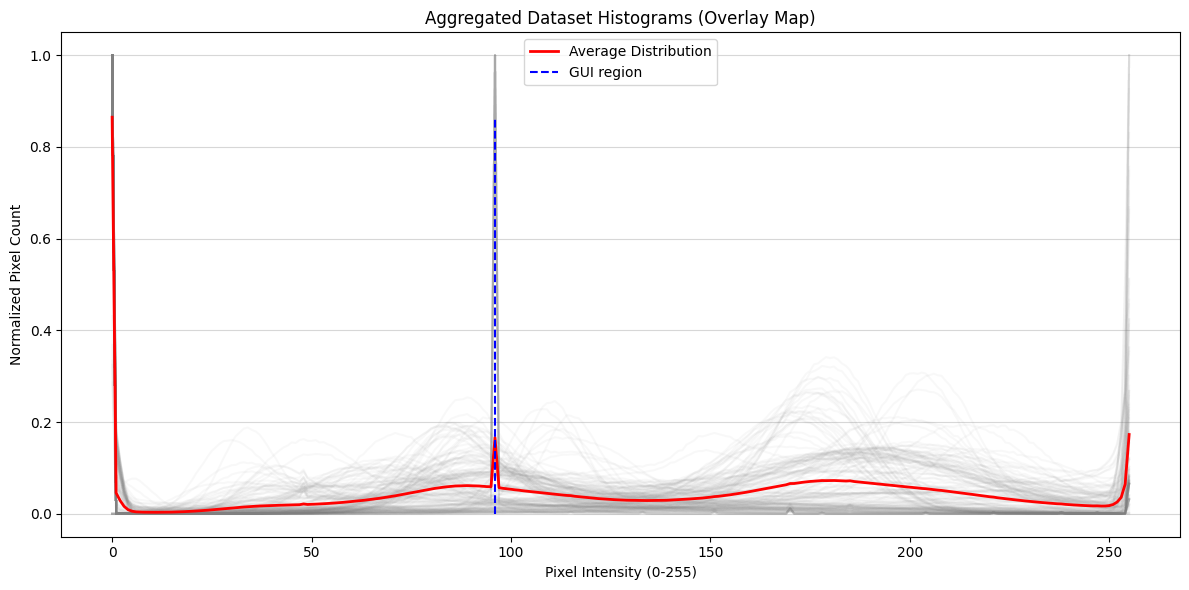

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

def visualize_aggregated_histograms(directory_path, extension="*.png"):
    search_pattern = os.path.join(directory_path, extension)
    image_files = glob.glob(search_pattern)
    
    if not image_files:
        print(f"No images found matching {search_pattern}")
        return

    all_histograms = []
    
    plt.figure(figsize=(12, 6))

    for img_path in image_files:
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is not None:
            hist = cv2.calcHist([image], [0], None, [256], [0, 256])
            
            cv2.normalize(hist, hist, alpha=0, beta=1, norm_type=cv2.NORM_MINMAX)
            all_histograms.append(hist)
            
            plt.plot(hist, color='gray', alpha=0.05)

    if not all_histograms:
        return

    avg_hist = np.mean(all_histograms, axis=0)
    plt.plot(avg_hist, color='red', linewidth=2, label='Average Distribution')

    plt.vlines([96], ymin=0, ymax=max(avg_hist), colors='blue', linestyles='dashed', label='GUI region')

    plt.title('Aggregated Dataset Histograms (Overlay Map)')
    plt.xlabel('Pixel Intensity (0-255)')
    plt.ylabel('Normalized Pixel Count')
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.tight_layout()
    plt.show()

visualize_aggregated_histograms('data/raw_images/')

# 5. Analiza niedoświetlenia i prześwietlenia

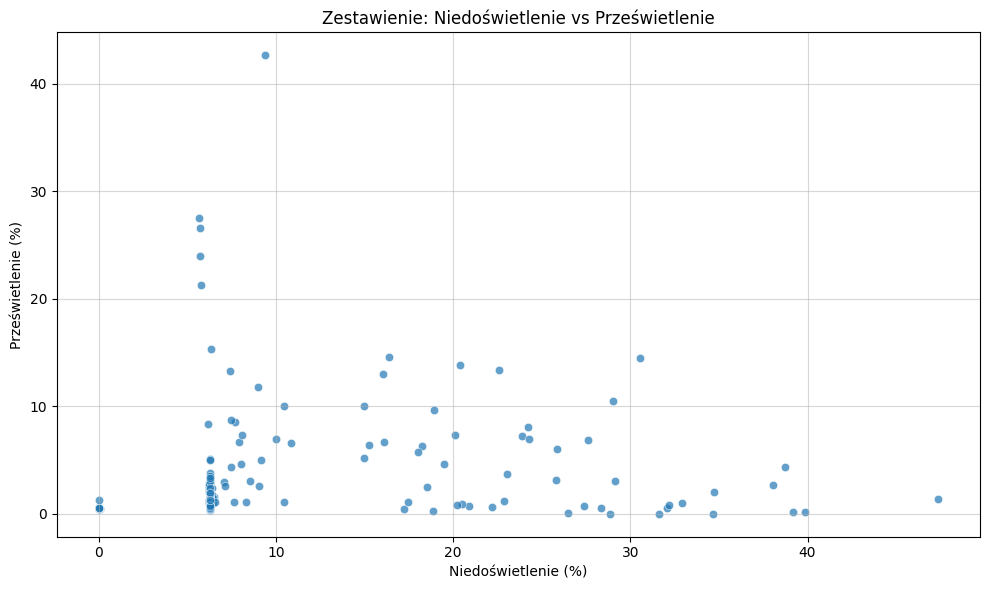

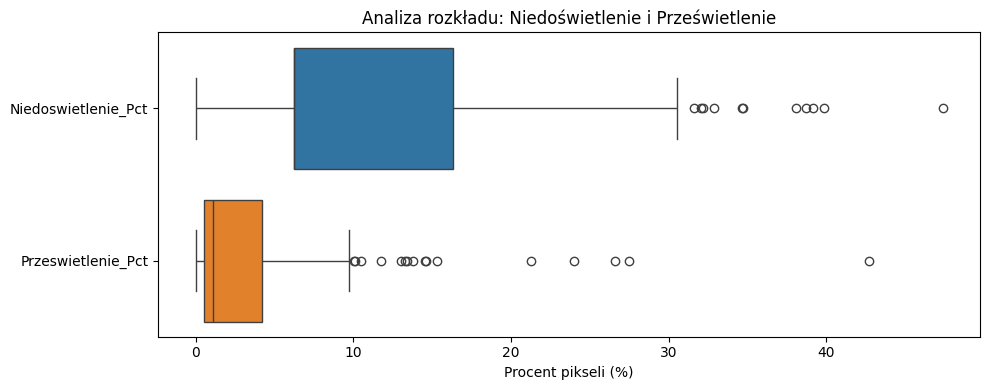

In [13]:
def analyze_exposure_clipping(directory_path, extension="*.png"):
    search_pattern = os.path.join(directory_path, extension)
    image_files = glob.glob(search_pattern)
    
    if not image_files:
        print(f"Brak plików: {search_pattern}")
        return

    statistics = []

    for img_path in image_files:
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        
        if image is not None:
            total_pixels = image.size
            statistics.append({
                "Plik": os.path.basename(img_path),
                "Niedoswietlenie_Pct": (np.sum(image < 5) / total_pixels) * 100,
                "Przeswietlenie_Pct": (np.sum(image > 250) / total_pixels) * 100
            })

    df = pd.DataFrame(statistics)
    
    analysis_df = df.drop(columns=['Plik'])
    
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=analysis_df, x="Niedoswietlenie_Pct", y="Przeswietlenie_Pct", alpha=0.7)
    plt.title("Zestawienie: Niedoświetlenie vs Prześwietlenie")
    plt.xlabel("Niedoświetlenie (%)")
    plt.ylabel("Prześwietlenie (%)")
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.boxplot(data=analysis_df, orient="h")
    plt.title("Analiza rozkładu: Niedoświetlenie i Prześwietlenie")
    plt.xlabel("Procent pikseli (%)")
    plt.tight_layout()
    plt.show()

analyze_exposure_clipping('data/raw_images/')

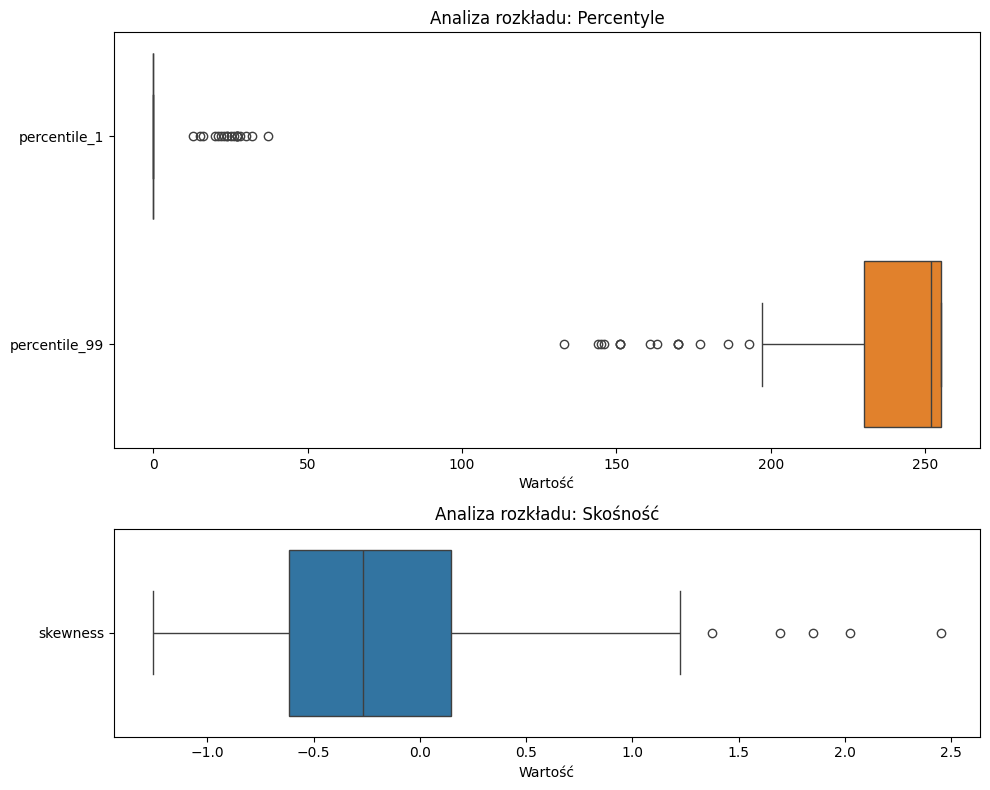

In [18]:
def analyse_percentiles_and_skewness(directory_path, extension="*.png"):
    search_pattern = os.path.join(directory_path, extension)
    image_files = glob.glob(search_pattern)
    
    if not image_files:
        print(f"Brak plików: {search_pattern}")
        return

    statistics = []

    for img_path in image_files:
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is not None:

            percentile_1 = np.percentile(image, 1)
            percentile_99 = np.percentile(image, 99)

            skewness = skew(image.ravel())

            statistics.append({
                "percentile_1": percentile_1,
                "percentile_99": percentile_99,
                "skewness": skewness
            })

    if not statistics:
        return

    df = pd.DataFrame(statistics)

    fig, axs = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={'height_ratios': [2, 1]})

    sns.boxplot(data=df[["percentile_1", "percentile_99"]], orient="h", ax=axs[0])
    axs[0].set_title("Analiza rozkładu: Percentyle")
    axs[0].set_xlabel("Wartość")
    
    sns.boxplot(data=df[["skewness"]], orient="h", ax=axs[1])
    axs[1].set_title("Analiza rozkładu: Skośność")
    axs[1].set_xlabel("Wartość")

    plt.tight_layout()
    plt.show()

analyse_percentiles_and_skewness('data/raw_images/')